In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('startup_funding.csv', encoding='latin-1')
df.head()

,ï»¿Sr No,Date dd/mm/yyyy,Startup Name,Industry Vertical,SubVertical,City Location,Investors Name,InvestmentnType,Amount in USD,Remarks
0,1,09/01/2020,BYJUâS,E-Tech,E-learning,Bengaluru,Tiger Global Management,Private Equity Round,"20,00,00,000",NaN
1,2,13/01/2020,Shuttl,Transportation,App based shuttle service,Gurgaon,Susquehanna Growth Equity,Series C,"80,48,394",NaN
2,3,09/01/2020,Mamaearth,E-commerce,Retailer of baby and toddler products,Bengaluru,Sequoia Capital India,Series B,"1,83,58,860",NaN
3,4,02/01/2020,https://www.wealthbucket.in/,FinTech,Online Investment,New Delhi,Vinod Khatumal,Pre-series A,"30,00,000",NaN
4,5,02/01/2020,Fashor,Fashion and Apparel,Embroiled Clothes For Women,Mumbai,Sprout Venture Partners,Seed Round,"18,00,000",NaN


In [3]:
df.shape


(3044, 10)

In [14]:
df.head(50)

,Date dd/mm/yyyy,Startup Name,Industry Vertical,City Location,Investors Name,InvestmentnType,Amount in USD
0,09/01/2020,BYJUâS,E-Tech,Bengaluru,Tiger Global Management,Private Equity Round,"20,00,00,000"
1,13/01/2020,Shuttl,Transportation,Gurgaon,Susquehanna Growth Equity,Series C,"80,48,394"
2,09/01/2020,Mamaearth,E-commerce,Bengaluru,Sequoia Capital India,Series B,"1,83,58,860"
3,02/01/2020,https://www.wealthbucket.in/,FinTech,New Delhi,Vinod Khatumal,Pre-series A,"30,00,000"
4,02/01/2020,Fashor,Fashion and Apparel,Mumbai,Sprout Venture Partners,Seed Round,"18,00,000"
5,13/01/2020,Pando,Logistics,Chennai,Chiratae Ventures,Series A,"90,00,000"
6,10/01/2020,Zomato,Hospitality,Gurgaon,Ant Financial,Private Equity Round,"15,00,00,000"
7,12/12/2019,Ecozen,Technology,Pune,Sathguru Catalyzer Advisors,Series A,"60,00,000"
8,06/12/2019,CarDekho,E-Commerce,Gurgaon,Ping An Global Voyager Fund,Series D,"7,00,00,000"
9,03/12/2019,Dhruva Space,Aerospace,Bengaluru,"Mumbai Angels, Ravikanth Reddy",Seed,"5,00,00,000"


In [5]:
df.isnull().sum()

,0
ï»¿Sr No,0
Date dd/mm/yyyy,0
Startup Name,0
Industry Vertical,171
SubVertical,936
City Location,180
Investors Name,24
InvestmentnType,4
Amount in USD,960
Remarks,2625


In [7]:
df = df.drop(columns=['Remarks', 'SubVertical', 'ï»¿Sr No'])


In [8]:
df = df.dropna(subset=['Industry Vertical', 'City  Location'])

In [9]:
df['Investors Name'] = df['Investors Name'].fillna('Undisclosed')

In [10]:
df.shape

(2864, 7)

In [13]:
df.head(50)

,Date dd/mm/yyyy,Startup Name,Industry Vertical,City Location,Investors Name,InvestmentnType,Amount in USD
0,09/01/2020,BYJUâS,E-Tech,Bengaluru,Tiger Global Management,Private Equity Round,"20,00,00,000"
1,13/01/2020,Shuttl,Transportation,Gurgaon,Susquehanna Growth Equity,Series C,"80,48,394"
2,09/01/2020,Mamaearth,E-commerce,Bengaluru,Sequoia Capital India,Series B,"1,83,58,860"
3,02/01/2020,https://www.wealthbucket.in/,FinTech,New Delhi,Vinod Khatumal,Pre-series A,"30,00,000"
4,02/01/2020,Fashor,Fashion and Apparel,Mumbai,Sprout Venture Partners,Seed Round,"18,00,000"
5,13/01/2020,Pando,Logistics,Chennai,Chiratae Ventures,Series A,"90,00,000"
6,10/01/2020,Zomato,Hospitality,Gurgaon,Ant Financial,Private Equity Round,"15,00,00,000"
7,12/12/2019,Ecozen,Technology,Pune,Sathguru Catalyzer Advisors,Series A,"60,00,000"
8,06/12/2019,CarDekho,E-Commerce,Gurgaon,Ping An Global Voyager Fund,Series D,"7,00,00,000"
9,03/12/2019,Dhruva Space,Aerospace,Bengaluru,"Mumbai Angels, Ravikanth Reddy",Seed,"5,00,00,000"


In [17]:
df['Amount in USD'] = df['Amount in USD'].astype(str)
df['Amount in USD'] = df['Amount in USD'].str.replace(',', '')
df['Amount in USD'] = pd.to_numeric(df['Amount in USD'], errors='coerce')

In [18]:
df['Amount in INR (Crore)'] = (df['Amount in USD'] * 96) / 10000000

In [19]:
df.head()

,Date dd/mm/yyyy,Startup Name,Industry Vertical,City Location,Investors Name,InvestmentnType,Amount in USD,Amount in INR (Crore)
0,09/01/2020,BYJUâS,E-Tech,Bengaluru,Tiger Global Management,Private Equity Round,200000000.0,1920.000000
1,13/01/2020,Shuttl,Transportation,Gurgaon,Susquehanna Growth Equity,Series C,8048394.0,77.264582
2,09/01/2020,Mamaearth,E-commerce,Bengaluru,Sequoia Capital India,Series B,18358860.0,176.245056
3,02/01/2020,https://www.wealthbucket.in/,FinTech,New Delhi,Vinod Khatumal,Pre-series A,3000000.0,28.800000
4,02/01/2020,Fashor,Fashion and Apparel,Mumbai,Sprout Venture Partners,Seed Round,1800000.0,17.280000


/tmp/ipykernel_2026/2996205631.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_sectors.values, y=top_sectors.index, palette='viridis')


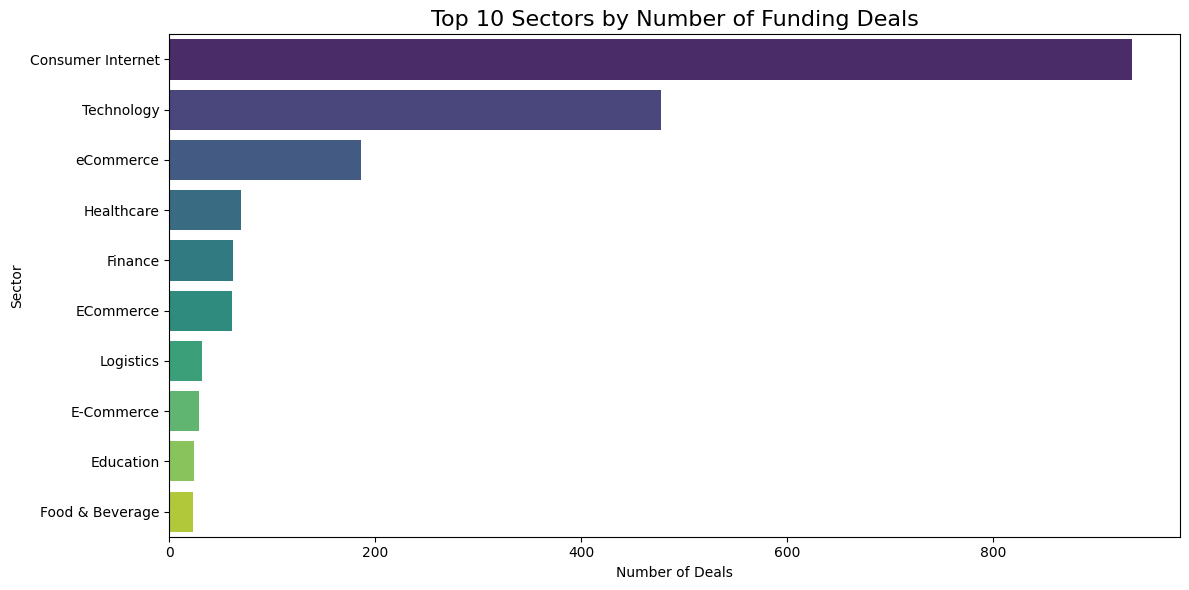

In [20]:
top_sectors = df['Industry Vertical'].value_counts().head(10)

plt.figure(figsize=(12,6))
sns.barplot(x=top_sectors.values, y=top_sectors.index, palette='viridis')
plt.title('Top 10 Sectors by Number of Funding Deals', fontsize=16)
plt.xlabel('Number of Deals')
plt.ylabel('Sector')
plt.tight_layout()
plt.show()

/tmp/ipykernel_2026/3260572615.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_cities.values, y=top_cities.index, palette='viridis')


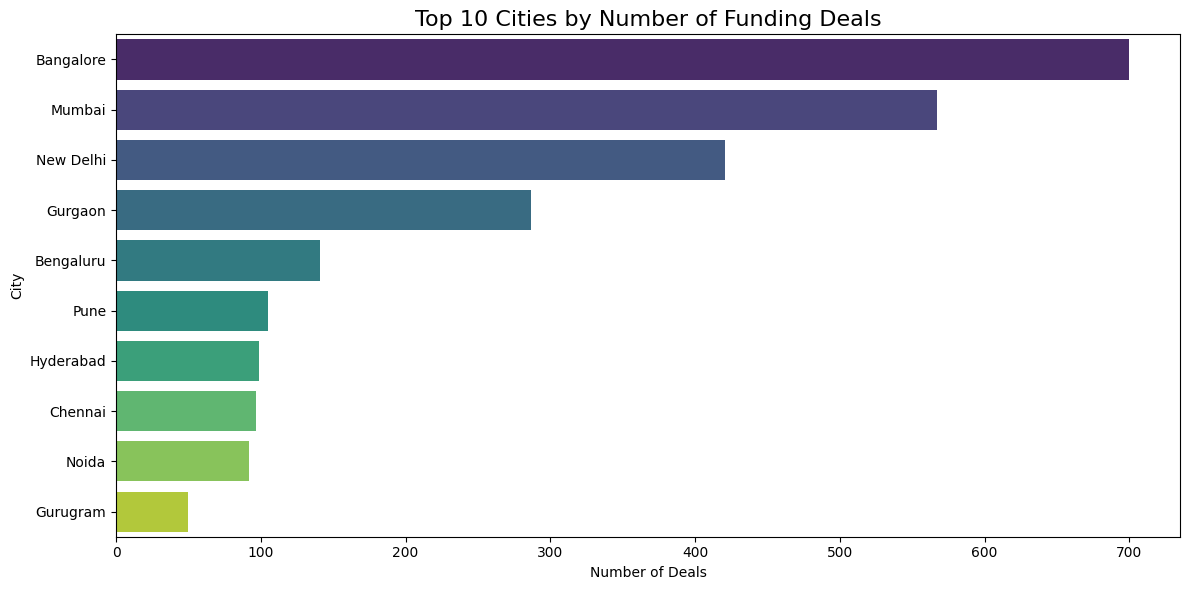

In [21]:
top_cities = df['City  Location'].value_counts().head(10)

plt.figure(figsize=(12,6))
sns.barplot(x=top_cities.values, y=top_cities.index, palette='viridis')
plt.title('Top 10 Cities by Number of Funding Deals', fontsize=16)
plt.xlabel('Number of Deals')
plt.ylabel('City')
plt.tight_layout()
plt.show()

/tmp/ipykernel_2026/2086318666.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_investors.values, y=top_investors.index, palette='viridis')


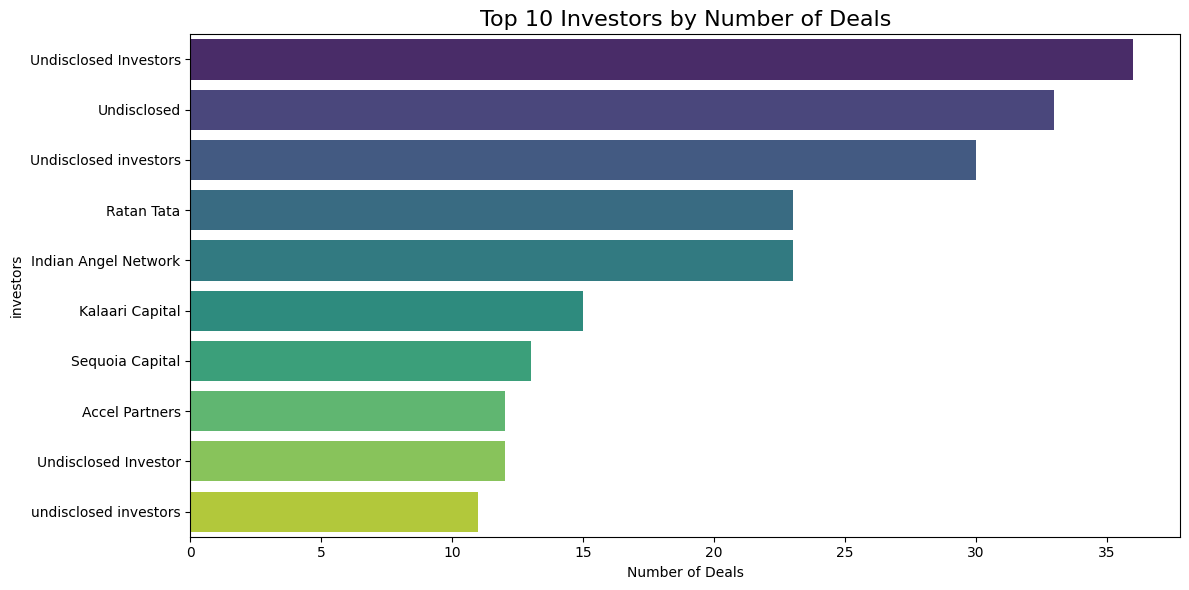

In [22]:
top_investors = df['Investors Name'].value_counts().head(10)
plt.figure(figsize=(12,6))
sns.barplot(x=top_investors.values, y=top_investors.index, palette='viridis')
plt.title('Top 10 Investors by Number of Deals', fontsize=16)
plt.xlabel('Number of Deals')
plt.ylabel('investors')
plt.tight_layout()
plt.show()

In [23]:
mask = df['Investors Name'].str.lower().str.contains('undisclosed', na=False)
df_known = df[~mask]

/tmp/ipykernel_2026/487524319.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_investors.values, y=top_investors.index, palette='viridis')


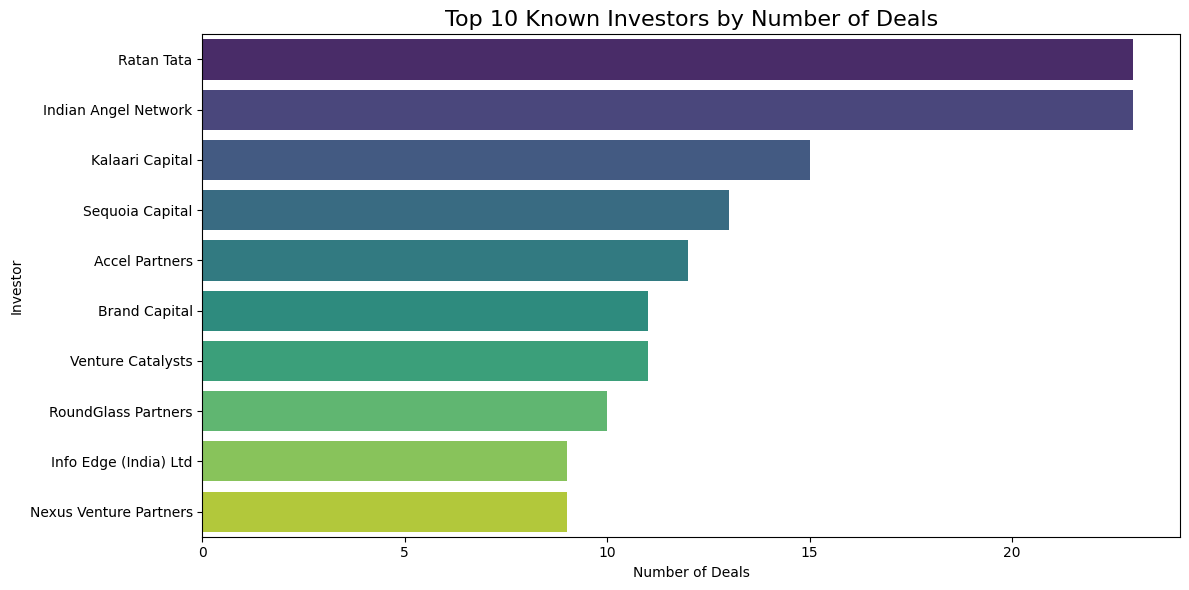

In [24]:
top_investors = df_known['Investors Name'].value_counts().head(10)

plt.figure(figsize=(12,6))
sns.barplot(x=top_investors.values, y=top_investors.index, palette='viridis')
plt.title('Top 10 Known Investors by Number of Deals', fontsize=16)
plt.xlabel('Number of Deals')
plt.ylabel('Investor')
plt.tight_layout()
plt.show()

In [25]:
df['Date dd/mm/yyyy'] = pd.to_datetime(df['Date dd/mm/yyyy'],
                                        format='%d/%m/%Y',
                                        errors='coerce')
df['Year'] = df['Date dd/mm/yyyy'].dt.year


In [26]:
yearly_deals = df.groupby('Year')['Startup Name'].count().reset_index()
yearly_deals.columns = ['Year', 'Number of Deals']

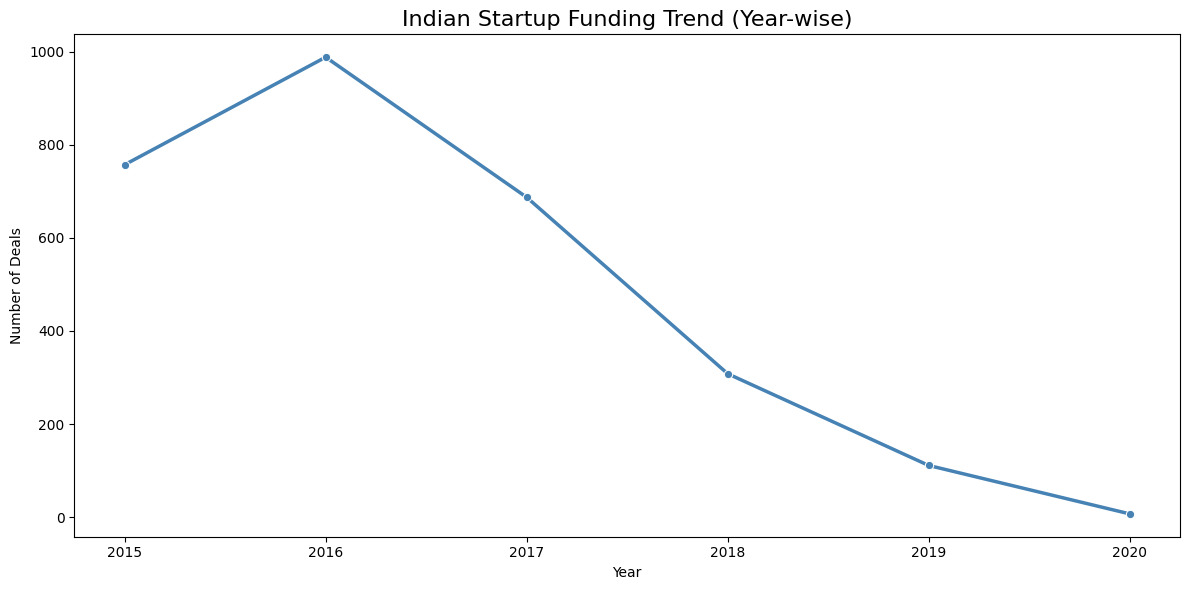

In [27]:
plt.figure(figsize=(12,6))
sns.lineplot(x='Year', y='Number of Deals', data=yearly_deals,
             marker='o', linewidth=2.5, color='steelblue')
plt.title('Indian Startup Funding Trend (Year-wise)', fontsize=16)
plt.xlabel('Year')
plt.ylabel('Number of Deals')
plt.tight_layout()
plt.show()

In [28]:
print(df['Year'].value_counts().sort_index())

Year
2015.0    757
2016.0    988
2017.0    687
2018.0    308
2019.0    111
2020.0      7
Name: count, dtype: int64


In [29]:
top_startups = df.groupby('Startup Name')['Amount in USD'].sum().sort_values(ascending=False).head(10)

/tmp/ipykernel_2026/3294739619.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_startups.values, y=top_startups.index, palette='viridis')


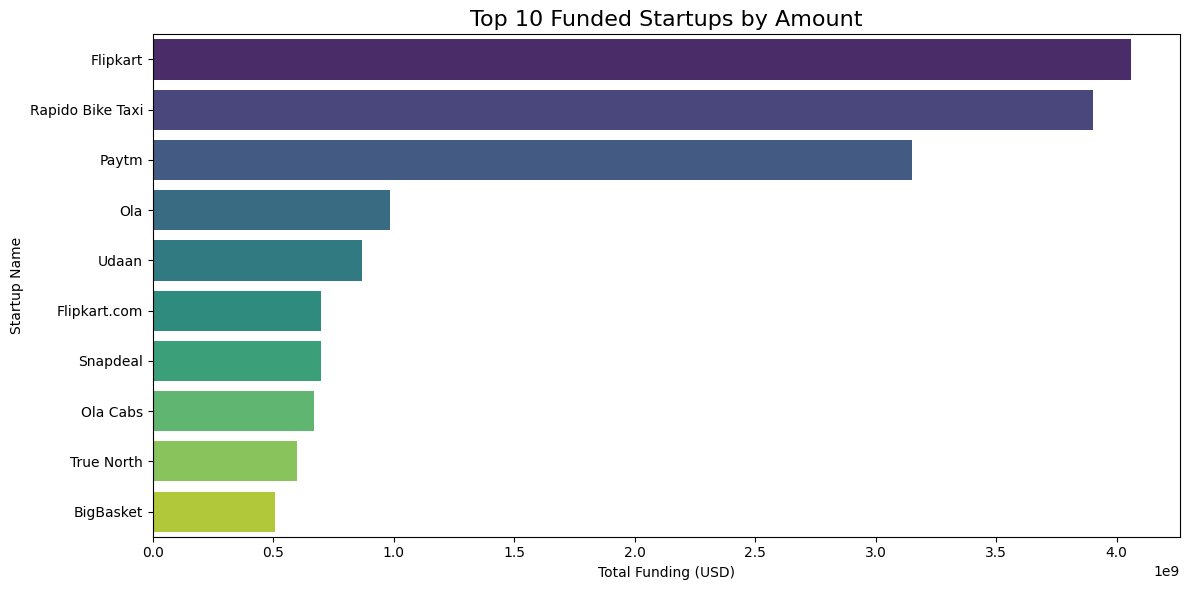

In [30]:
top_startups = df.groupby('Startup Name')['Amount in USD'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))
sns.barplot(x=top_startups.values, y=top_startups.index, palette='viridis')
plt.title('Top 10 Funded Startups by Amount', fontsize=16)
plt.xlabel('Total Funding (USD)')
plt.ylabel('Startup Name')
plt.tight_layout()
plt.show()

In [31]:
df.to_csv('startup_funding_cleaned.csv', index=False)